# EDA: анализ данных кейса "Потеряшки"

Цели ноутбука:
- понять структуру и качество доступных данных
- проверить временную динамику и прокси для окна инцидента
- оценить разреженность взаимодействий user-item
- изучить профили пользователей и изданий (long-tail, cold-start)
- сформулировать практические выводы для candidate generation и ranking

In [3]:
from pathlib import Path
import sys

# Fix path FIRST, before any src imports
repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

# Now import src
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.platform.core.dataset import Dataset

pd.set_option("display.max_columns", 200)

data_dir = repo_root / "data"
dataset = Dataset.load(data_dir)

data_dir

WindowsPath('C:/Users/user/Desktop/project/nto-ai-25-26-final-baseline/data')

In [4]:
frames = {
    "interactions_df": dataset.interactions_df,
    "targets_df": dataset.targets_df,
    "catalog_df": dataset.catalog_df,
    "authors_df": dataset.authors_df,
    "book_genres_df": dataset.book_genres_df,
    "genres_df": dataset.genres_df,
    "users_df": dataset.users_df,
    "seen_positive_df": dataset.seen_positive_df,
}

summary = pd.DataFrame(
    {
        "name": list(frames.keys()),
        "rows": [len(frame) for frame in frames.values()],
        "columns": [list(frame.columns) for frame in frames.values()],
    }
)

summary

,name,rows,columns
0,interactions_df,443278,"[user_id, edition_id, event_type, rating, even..."
1,targets_df,3862,[user_id]
2,catalog_df,460599,"[edition_id, book_id, author_id, publication_y..."
3,authors_df,100724,"[author_id, author_name]"
4,book_genres_df,413301,"[book_id, genre_id]"
5,genres_df,707,"[genre_id, genre_name]"
6,users_df,80738,"[user_id, gender, age]"
7,seen_positive_df,442870,"[user_id, edition_id]"


In [5]:
for name, frame in frames.items():
    print(f"\n{name}")
    display(frame.head(3))


interactions_df


,user_id,edition_id,event_type,rating,event_ts
0,10000240,1000450846,1,NaN,2025-07-12 15:10:47
1,10000240,1000530959,2,7.0,2025-07-14 16:19:15
2,10000240,1000733939,2,9.0,2025-07-15 12:36:55



targets_df


,user_id
0,10001560
1,10002550
2,1000350



catalog_df


...

,genre_id,genre_name
0,1,Бизнес-книги
1,10,UNKNOWN_GENRE_10
2,100,Финансовые-инструменты



users_df


,user_id,gender,age
0,10000030,1.0,61
1,10000060,2.0,60
2,10000090,2.0,19



seen_positive_df


,user_id,edition_id
0,10000240,1000450846
1,10000240,1000530959
2,10000240,1000733939


## 1) Базовые факты о задаче и окнах времени

По условию:
- позитив: `event_type in {1, 2}` (wishlist/read)
- предсказываем потерянные пары `(user_id, edition_id)`
- окно инцидента фиксировано: `2025-10-01 00:00:00` -> `2025-11-01 00:00:00`
- данные после `2025-11-01 00:00:00` (до конца ноября) считаем полностью наблюдаемыми и полезными для обучения

Ниже строим рабочие выборки и базовые метрики, которые нужны для проектирования baseline/feature pipeline.

In [10]:
interactions = dataset.interactions_df.copy()
positives = interactions[interactions["event_type"].isin([1, 2])].copy()

# Фиксированные окна из условия
incident_start_ts = pd.Timestamp("2025-10-01 00:00:00")
incident_end_ts = pd.Timestamp("2025-11-01 00:00:00")
post_incident_end_ts = pd.Timestamp("2025-12-01 00:00:00")

history_df = positives[positives["event_ts"] < incident_start_ts].copy()
incident_df = positives[
    (positives["event_ts"] >= incident_start_ts)
    & (positives["event_ts"] < incident_end_ts)
].copy()
post_incident_df = positives[
    (positives["event_ts"] >= incident_end_ts)
    & (positives["event_ts"] < post_incident_end_ts)
].copy()

max_ts = positives["event_ts"].max()

basic_stats = {
    "all_interactions_rows": len(interactions),
    "positive_rows": len(positives),
    "positive_pairs_unique": positives[["user_id", "edition_id"]].drop_duplicates().shape[0],
    "seen_positive_pairs_dataset": len(dataset.seen_positive_df),
    "users_with_positives": positives["user_id"].nunique(),
    "target_users": dataset.targets_df["user_id"].nunique(),
    "editions_with_positives": positives["edition_id"].nunique(),
    "catalog_editions": dataset.catalog_df["edition_id"].nunique(),
    "time_min": positives["event_ts"].min(),
    "time_max": max_ts,
    "incident_start": incident_start_ts,
    "incident_end": incident_end_ts,
    "post_incident_end": post_incident_end_ts,
    "history_rows": len(history_df),
    "incident_rows": len(incident_df),
    "post_incident_rows": len(post_incident_df),
}

pd.Series(basic_stats)

all_interactions_rows                       443278
positive_rows                               443278
positive_pairs_unique                       442870
seen_positive_pairs_dataset                 442870
users_with_positives                         19259
target_users                                  3862
editions_with_positives                     126002
catalog_editions                            460599
time_min                       2025-05-01 00:00:47
time_max                       2025-11-30 23:59:35
incident_start                 2025-10-01 00:00:00
incident_end                   2025-11-01 00:00:00
post_incident_end              2025-12-01 00:00:00
history_rows                                328465
incident_rows                                50200
post_incident_rows                           64613
dtype: object

In [11]:
## 2) Проверка качества данных

def frame_quality_report(name: str, df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "null_pct": [df[c].isna().mean() for c in df.columns],
        "nunique": [df[c].nunique(dropna=True) for c in df.columns],
    })
    out.insert(0, "frame", name)
    return out

quality_reports = []
for name, frame in frames.items():
    quality_reports.append(frame_quality_report(name, frame))

quality_df = pd.concat(quality_reports, ignore_index=True)
display(quality_df.sort_values(["frame", "null_pct"], ascending=[True, False]))

print("\nDuplicate checks:")
print("interactions duplicated rows:", interactions.duplicated().sum())
print("seen_positive duplicated pairs:", dataset.seen_positive_df.duplicated(["user_id", "edition_id"]).sum())
print("catalog duplicated edition_id:", dataset.catalog_df.duplicated(["edition_id"]).sum())
print("users duplicated user_id:", dataset.users_df.duplicated(["user_id"]).sum())

,frame,column,dtype,null_pct,nunique
16,authors_df,author_name,str,0.003773,98404
15,authors_df,author_id,int64,0.000000,100724
17,book_genres_df,book_id,int64,0.000000,252465
18,book_genres_df,genre_id,int64,0.000000,707
14,catalog_df,description,str,0.094288,401582
6,catalog_df,edition_id,int64,0.000000,460599
7,catalog_df,book_id,int64,0.000000,337245
8,catalog_df,author_id,int64,0.000000,100724
9,catalog_df,publication_year,int64,0.000000,201
10,catalog_df,age_restriction,int64,0.000000,21



Duplicate checks:
interactions duplicated rows: 0
seen_positive duplicated pairs: 0
catalog duplicated edition_id: 0
users duplicated user_id: 0


history_events          328465.000000
incident_events          50200.000000
post_incident_events     64613.000000
incident_share               0.113247
post_incident_share          0.145762
dtype: float64

,event_type,rows,share
0,1,184749,0.416779
1,2,258529,0.583221


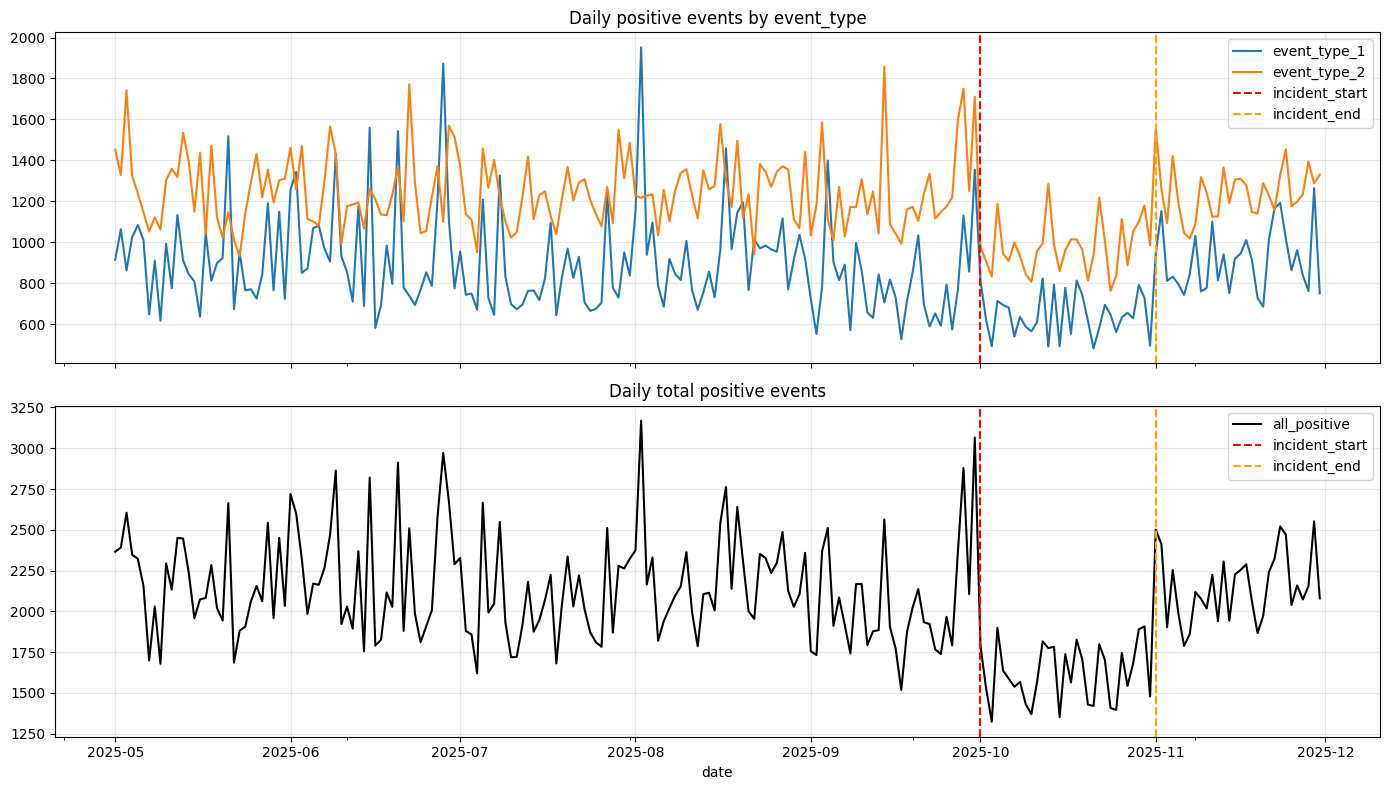

In [12]:
## 3) Временная динамика и структура событий

daily = (
    positives.assign(date=positives["event_ts"].dt.date)
    .groupby(["date", "event_type"], as_index=False)
    .size()
    .rename(columns={"size": "events"})
)

daily_pivot = daily.pivot(index="date", columns="event_type", values="events").fillna(0)
daily_pivot.columns = [f"event_type_{c}" for c in daily_pivot.columns]
daily_pivot["all_positive"] = daily_pivot.sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

daily_pivot[[c for c in daily_pivot.columns if c.startswith("event_type_")]].plot(ax=axes[0])
axes[0].axvline(incident_start_ts.date(), color="red", linestyle="--", label="incident_start")
axes[0].axvline(incident_end_ts.date(), color="orange", linestyle="--", label="incident_end")
axes[0].set_title("Daily positive events by event_type")
axes[0].legend()
axes[0].grid(alpha=0.3)

daily_pivot[["all_positive"]].plot(ax=axes[1], color="black")
axes[1].axvline(incident_start_ts.date(), color="red", linestyle="--", label="incident_start")
axes[1].axvline(incident_end_ts.date(), color="orange", linestyle="--", label="incident_end")
axes[1].set_title("Daily total positive events")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

window_stats = pd.Series(
    {
        "history_events": len(history_df),
        "incident_events": len(incident_df),
        "post_incident_events": len(post_incident_df),
        "incident_share": len(incident_df) / max(1, len(positives)),
        "post_incident_share": len(post_incident_df) / max(1, len(positives)),
    }
)

event_share = (
    positives.groupby("event_type", as_index=False)
    .size()
    .rename(columns={"size": "rows"})
)
event_share["share"] = event_share["rows"] / event_share["rows"].sum()

display(window_stats)
event_share

target_users_total                       3862.0
target_users_with_positive_history       3862.0
target_users_without_positive_history       0.0
share_target_without_history                0.0
dtype: float64

,count,mean,std,min,50%,75%,90%,95%,99%,max
is_target,,,,,,,,,,
0,15397.0,12.082938,44.396704,1.0,3.0,12.0,31.0,49.0,107.00,4328.0
1,3862.0,66.501554,125.465754,1.0,36.0,73.0,135.9,200.0,534.17,3436.0


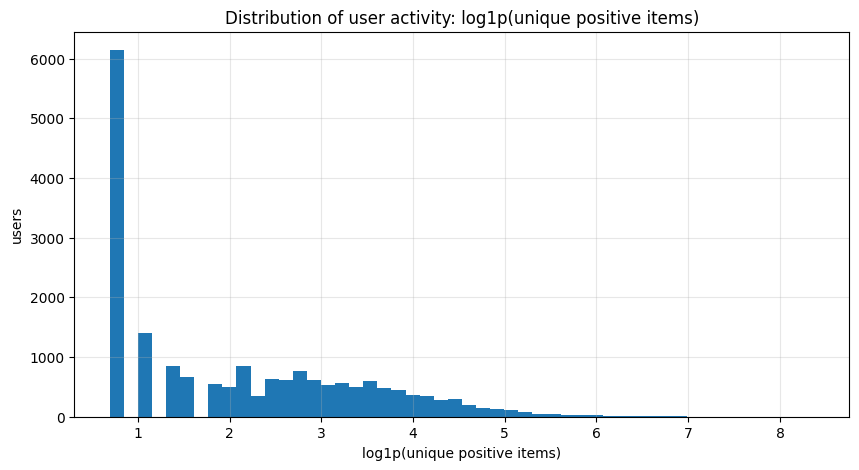

In [13]:
## 4) Пользователи: активность, покрытие targets, cold-start

user_pos_pairs = positives[["user_id", "edition_id"]].drop_duplicates()
user_activity = (
    user_pos_pairs.groupby("user_id", as_index=False)
    .size()
    .rename(columns={"size": "unique_positive_items"})
)

targets = dataset.targets_df[["user_id"]].drop_duplicates().assign(is_target=1)
user_activity = user_activity.merge(targets, on="user_id", how="left")
user_activity["is_target"] = user_activity["is_target"].fillna(0).astype(int)

target_users = set(dataset.targets_df["user_id"].unique())
users_with_any_history = set(user_activity["user_id"].unique())

coverage_stats = pd.Series(
    {
        "target_users_total": len(target_users),
        "target_users_with_positive_history": len(target_users & users_with_any_history),
        "target_users_without_positive_history": len(target_users - users_with_any_history),
        "share_target_without_history": len(target_users - users_with_any_history) / max(1, len(target_users)),
    }
)

display(coverage_stats)

display(
    user_activity.groupby("is_target")["unique_positive_items"]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
)

plt.figure(figsize=(10, 5))
plt.hist(np.log1p(user_activity["unique_positive_items"]), bins=50)
plt.title("Distribution of user activity: log1p(unique positive items)")
plt.xlabel("log1p(unique positive items)")
plt.ylabel("users")
plt.grid(alpha=0.3)
plt.show()

,top_k_items,interaction_share
0,10,0.009470
1,50,0.032213
2,100,0.052223
3,500,0.145361
4,1000,0.211913


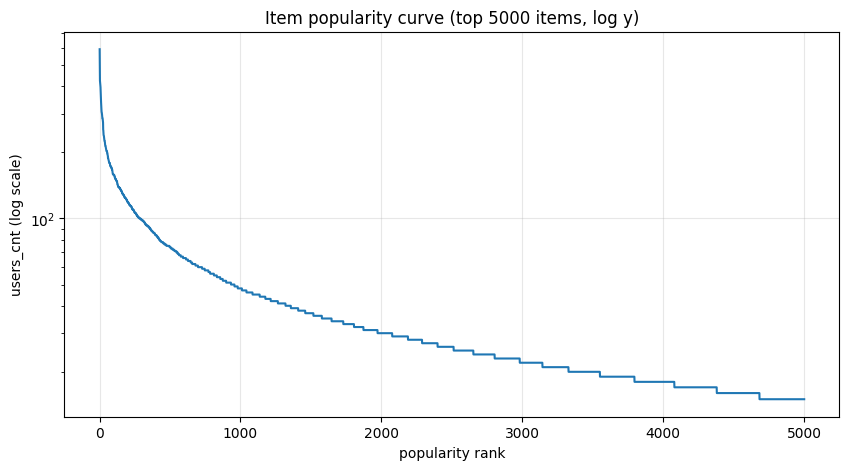

catalog_rows                 460599.000000
catalog_unique_editions      460599.000000
catalog_unique_books         337245.000000
catalog_unique_authors       100724.000000
missing_title_share               0.000000
missing_description_share         0.094288
dtype: float64

,genre_id,positive_pairs,genre_name
195,433.0,66382,Современная-зарубежная-литература
178,412.0,43904,Зарубежная-классика
191,426.0,36851,Зарубежное-фэнтези
498,1217.0,32342,Современная-проза
201,441.0,31826,Классическая-проза
90,127.0,28675,Зарубежные-детективы
273,533.0,28636,Современные-любовные-романы
88,125.0,27750,Триллеры
526,1251.0,27662,Отечественное-фэнтези
110,149.0,23007,Книги-для-подростков


,author_id,positive_pairs,author_name
13,48,4830,Стивен Кинг
298,1781,2581,Агата Кристи
10268,325813,2555,Анна Джейн
75,264,2500,Фёдор Достоевский
22516,1290387,2481,Лия Арден
7018,226694,2406,без автора
29552,2386468,2387,Виктор Дашкевич
0,0,2059,NaN
5661,179700,1986,Джоан Роулинг
16052,624400,1761,Ребекка Яррос


In [14]:
## 5) Издания и контент: long-tail, метаданные, жанры/авторы

item_pos_pairs = positives[["user_id", "edition_id"]].drop_duplicates()
item_popularity = (
    item_pos_pairs.groupby("edition_id", as_index=False)
    .size()
    .rename(columns={"size": "users_cnt"})
    .sort_values("users_cnt", ascending=False)
)

item_popularity["pop_rank"] = np.arange(1, len(item_popularity) + 1)
item_popularity["cum_share"] = item_popularity["users_cnt"].cumsum() / item_popularity["users_cnt"].sum()

top_share = pd.DataFrame(
    {
        "top_k_items": [10, 50, 100, 500, 1000],
        "interaction_share": [
            item_popularity.head(k)["users_cnt"].sum() / item_popularity["users_cnt"].sum()
            for k in [10, 50, 100, 500, 1000]
        ],
    }
)

display(top_share)

plt.figure(figsize=(10, 5))
plt.plot(item_popularity["pop_rank"].values[:5000], item_popularity["users_cnt"].values[:5000])
plt.yscale("log")
plt.title("Item popularity curve (top 5000 items, log y)")
plt.xlabel("popularity rank")
plt.ylabel("users_cnt (log scale)")
plt.grid(alpha=0.3)
plt.show()

catalog = dataset.catalog_df.copy()
content_quality = pd.Series(
    {
        "catalog_rows": len(catalog),
        "catalog_unique_editions": catalog["edition_id"].nunique(),
        "catalog_unique_books": catalog["book_id"].nunique(),
        "catalog_unique_authors": catalog["author_id"].nunique(),
        "missing_title_share": catalog["title"].isna().mean() if "title" in catalog.columns else np.nan,
        "missing_description_share": catalog["description"].isna().mean() if "description" in catalog.columns else np.nan,
    }
)

display(content_quality)

# Жанровая агрегация по наблюдаемым позитивам
item_with_book = item_pos_pairs.merge(catalog[["edition_id", "book_id", "author_id"]], on="edition_id", how="left")

genre_pop = (
    item_with_book.merge(dataset.book_genres_df, on="book_id", how="left")
    .groupby("genre_id", as_index=False)
    .size()
    .rename(columns={"size": "positive_pairs"})
    .merge(dataset.genres_df, on="genre_id", how="left")
    .sort_values("positive_pairs", ascending=False)
)

author_pop = (
    item_with_book.groupby("author_id", as_index=False)
    .size()
    .rename(columns={"size": "positive_pairs"})
    .merge(dataset.authors_df, on="author_id", how="left")
    .sort_values("positive_pairs", ascending=False)
)

display(genre_pop.head(15))
display(author_pop.head(15))

## 6) Выводы для baseline-модели

На основе EDA обычно подтверждаются следующие рабочие гипотезы (проверьте на ваших числах после выполнения ячеек):

1. **Сильная разреженность user-item матрицы.**
   Нужны агрегационные/коллаборативные признаки и хороший candidate generation, а не только content-only.

2. **Long-tail по изданиям.**
   Полезно смешивать источники кандидатов: персональные (по истории пользователя) + popularity/backoff.

3. **Часть target-пользователей может быть с очень короткой историей или без нее.**
   Нужен fallback (глобально популярные / популярные в близких сегментах users).

4. **Временные окна нужно учитывать явно:**
   `2025-10-01` -> `2025-11-01` как инцидент и `2025-11-01` -> `2025-12-01` как полностью наблюдаемое окно.
   Нужны temporal-признаки: recency, счетчики по окнам (7/14/30/90), тренды по автору/жанру.

5. **Жанры/авторы дают устойчивые предпочтения.**
   Имеет смысл добавить affinity-features: user-author, user-genre, user-language, user-publisher.

Практически для следующего шага:
- реализовать признаки в `src/competition/features.py`
- расширить генерацию кандидатов в `src/competition/generators/`
- переоценить локально через пайплайн и сравнить NDCG@20 на валидации

In [15]:
# 7) Разреженность матрицы user-item (по позитивным уникальным парам)

n_users = positives["user_id"].nunique()
n_items = positives["edition_id"].nunique()
n_pairs = positives[["user_id", "edition_id"]].drop_duplicates().shape[0]

density = n_pairs / max(1, (n_users * n_items))

pd.Series(
    {
        "users": n_users,
        "items": n_items,
        "unique_positive_pairs": n_pairs,
        "matrix_density": density,
        "matrix_sparsity": 1 - density,
    }
)

users                     19259.000000
items                    126002.000000
unique_positive_pairs    442870.000000
matrix_density                0.000183
matrix_sparsity               0.999817
dtype: float64

,count,mean,std,min,50%,75%,90%,95%,99%,max
is_target,,,,,,,,,,
0,15397.0,83.162564,65.662726,0.0,75.0,138.0,181.0,197.0,210.00,213.0
1,3862.0,15.248576,22.144807,0.0,6.0,21.0,45.0,55.0,105.39,212.0


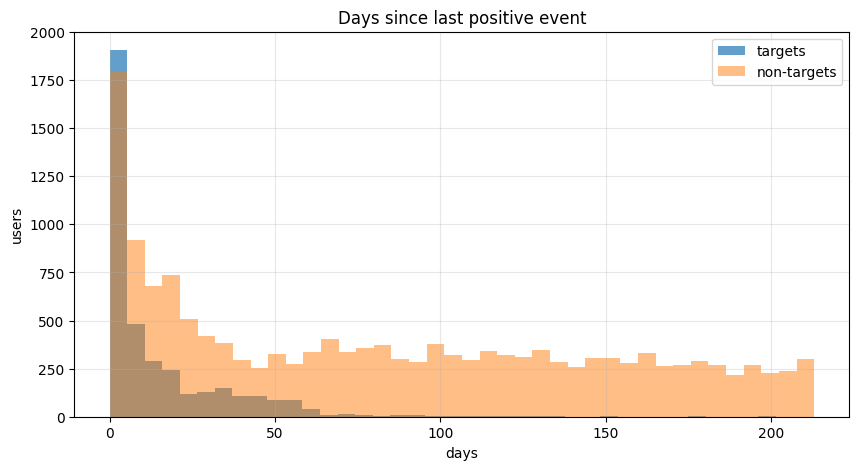

In [16]:
# 8) Recency по пользователям (насколько свежа история)

user_last_ts = positives.groupby("user_id", as_index=False)["event_ts"].max().rename(columns={"event_ts": "last_event_ts"})
user_last_ts["days_since_last_event"] = (max_ts - user_last_ts["last_event_ts"]).dt.days
user_last_ts = user_last_ts.merge(targets, on="user_id", how="left")
user_last_ts["is_target"] = user_last_ts["is_target"].fillna(0).astype(int)

display(
    user_last_ts.groupby("is_target")["days_since_last_event"]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
)

plt.figure(figsize=(10, 5))
plt.hist(user_last_ts[user_last_ts["is_target"] == 1]["days_since_last_event"], bins=40, alpha=0.7, label="targets")
plt.hist(user_last_ts[user_last_ts["is_target"] == 0]["days_since_last_event"], bins=40, alpha=0.5, label="non-targets")
plt.title("Days since last positive event")
plt.xlabel("days")
plt.ylabel("users")
plt.legend()
plt.grid(alpha=0.3)
plt.show()